# Predicción de Ingresos Totales del Canal de Panamá
## Modelo: SVR (Support Vector Regression)

## ¿Qué es SVR (Support Vector Regression)?

SVR es una adaptación de las **Support Vector Machines (SVM)** para problemas de regresión. Mientras que SVM busca el hiperplano que mejor separa clases en clasificación, SVR busca el hiperplano que mejor ajusta los datos manteniendo la mayor "planitud" posible.

### Tubo ε-insensible
SVR define un **tubo de tolerancia ε** alrededor del hiperplano de predicción. Los errores de predicción que caen **dentro** de este tubo se consideran aceptables y no penalizan la función de pérdida. Solo los puntos que caen **fuera** del tubo contribuyen al error, lo que hace al modelo robusto ante ruido pequeño.

### Margen y regularización
El objetivo es encontrar un hiperplano que:
1. Mantenga la mayoría de los puntos dentro del tubo ε.
2. Sea lo más **plano** posible (minimizar la complejidad del modelo).
3. El parámetro **C** controla el trade-off: valores altos de C penalizan más los errores fuera del tubo (modelo más flexible), mientras que valores bajos priorizan la planitud (más regularización).

### Truco del kernel
Para capturar relaciones **no lineales**, SVR utiliza el **kernel trick**, que proyecta los datos a espacios de mayor dimensionalidad donde es posible encontrar un hiperplano lineal. Los kernels más comunes son:
- **RBF (Radial Basis Function)**: el más versátil, captura relaciones no lineales complejas.
- **Lineal**: relaciones lineales entre features y target.
- **Polinomial**: relaciones polinomiales de grado específico.

### Hiperparámetros clave
- **C**: Regularización. Alto C = menos tolerancia a errores fuera del tubo (puede sobreajustar). Bajo C = más tolerancia (modelo más suave).
- **epsilon (ε)**: Ancho del tubo insensible. Un ε mayorignora más errores pero puede perder sensibilidad a patrones reales.
- **gamma** (para RBF): Controla la influencia de cada punto de entrenamiento. Alto gamma = cada punto tiene influencia local (puede sobreajustar). Bajo gamma = influencia más suavizada.

### Ventajas
- Efectivo en espacios de **alta dimensionalidad**.
- **Eficiente en memoria** (solo usa un subconjunto de puntos como vectores de soporte).
- **Versátil** gracias a la elección de kernel.
- Robustez ante outliers moderados (por el tubo ε-insensible).

### Limitaciones
- **Sensible al escalado de features**: requiere normalización/estandarización previa.
- No escala bien con **datasets muy grandes** (complejidad cuadrática/cúbica).
- **Menos interpretable** que modelos lineales o árboles de decisión.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

Matplotlib is building the font cache; this may take a moment.


## 1. Carga y Preparación de Datos

In [2]:
df = pd.read_csv("A07607236202602121443442025_transporte_acp.csv", encoding='latin-1')

df = df.rename(columns={
    "Ingresos por Peaje Panamax": "Ingresos Panamax",
    "Ingresos por Peaje NeoPanamax": "Ingresos NeoPanamax",
    "Tonelada Netas Neopanamax": "Toneladas Netas NeoPanamax"
})

df["Ingresos Totales"] = df["Ingresos Panamax"] + df["Ingresos NeoPanamax"]
df["Total Transitos"] = (
    df["Transito de Naves Alto Calado Panamax"]
    + df["Transito de Naves Pequeño Calado Panamax"]
    + df["Transito de Naves NeoPanamax"]
)
df["Total Toneladas"] = df["Toneladas Netas Panamax"] + df["Toneladas Netas NeoPanamax"]
df["Total Volumen"] = df["Volumen de Carga Panamax"] + df["Volumen de Carga NeoPanamax"]

meses = {
    "Enero": 1, "Febrero": 2, "Marzo": 3, "Abril": 4,
    "Mayo": 5, "Junio": 6, "Julio": 7, "Agosto": 8,
    "Septiembre": 9, "Octubre": 10, "Noviembre": 11, "Diciembre": 12
}
df["Num_Mes"] = df["Mes"].map(meses)
df["Mes_Indice"] = range(len(df))

print(f"Dimensiones del dataset: {df.shape}")
df.head()

Dimensiones del dataset: (72, 17)


,Año,Mes,Transito de Naves Alto Calado Panamax,Transito de Naves Pequeño Calado Panamax,Ingresos Panamax,Toneladas Netas Panamax,Volumen de Carga Panamax,Transito de Naves NeoPanamax,Ingresos NeoPanamax,Toneladas Netas NeoPanamax,Volumen de Carga NeoPanamax,Ingresos Totales,Total Transitos,Total Toneladas,Total Volumen,Num_Mes,Mes_Indice
0,2020,Enero,826,149,110198056,21167387,13324583,308,135551279,23811798,9311252,245749335,1283,44979185,22635835,1,0
1,2020,Febrero,753,206,100158695,19293825,13054336,268,112186169,19811487,8662008,212344864,1227,39105312,21716344,2,1
2,2020,Marzo,825,124,110757041,21512145,15397768,261,105134233,19232310,7836721,215891274,1210,40744455,23234489,3,2
3,2020,Abril,698,53,96144271,17615626,13232901,271,121704852,19898460,9636220,217849123,1022,37514086,22869121,4,3
4,2020,Mayo,640,43,85960793,15530225,12631808,254,115570390,18800359,7521629,201531183,937,34330584,20153437,5,4


## 2. Selección de Features y División de Datos

**Nota importante:** SVR es muy sensible a la escala de las features. Es **fundamental** aplicar escalado (StandardScaler) antes de entrenar el modelo, ya que el algoritmo se basa en distancias entre puntos.

In [3]:
features = [
    "Transito de Naves Alto Calado Panamax",
    "Transito de Naves Pequeño Calado Panamax",
    "Toneladas Netas Panamax",
    "Volumen de Carga Panamax",
    "Transito de Naves NeoPanamax",
    "Toneladas Netas NeoPanamax",
    "Volumen de Carga NeoPanamax",
    "Total Transitos",
    "Total Toneladas",
    "Total Volumen",
    "Num_Mes",
    "Mes_Indice"
]

target = "Ingresos Totales"

train = df[df["Año"] < 2025]
val = df[df["Año"] == 2025]

X_train = train[features].copy()
y_train = train[target].copy()
X_val = val[features].copy()
y_val = val[target].copy()

# Scale features (critical for SVR)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
X_val_scaled = scaler_X.transform(X_val)

print(f"Datos de entrenamiento: {X_train.shape[0]} registros (2020-2024)")
print(f"Datos de validación:    {X_val.shape[0]} registros (2025)")
print(f"\nFeatures y target escalados con StandardScaler")

Datos de entrenamiento: 60 registros (2020-2024)
Datos de validación:    12 registros (2025)

Features y target escalados con StandardScaler


## 3. Búsqueda de Hiperparámetros (C y epsilon)

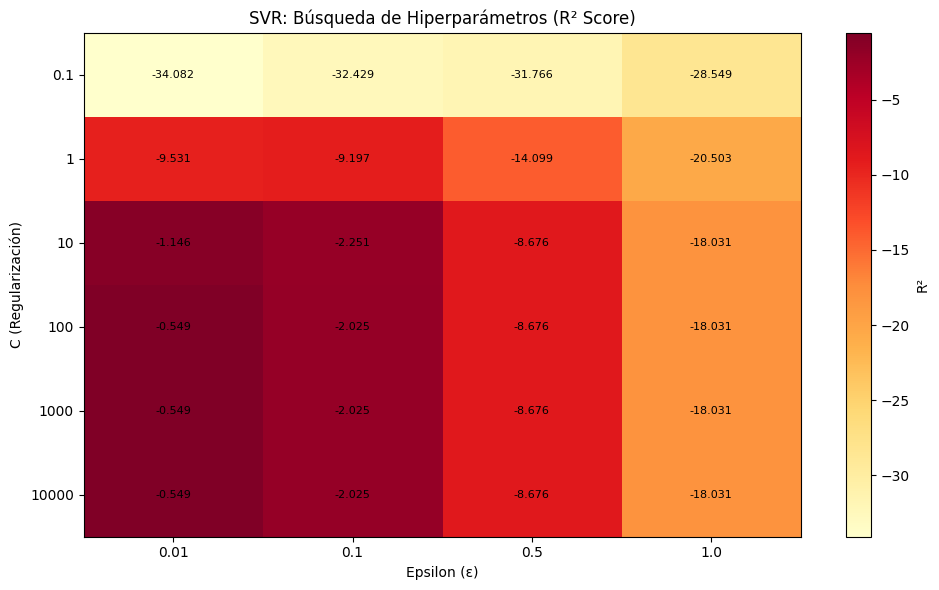

Mejores hiperparámetros: C=100.0, epsilon=0.01, R²=-0.5491


In [4]:
C_values = [0.1, 1, 10, 100, 1000, 10000]
eps_values = [0.01, 0.1, 0.5, 1.0]
results = []

for C in C_values:
    for eps in eps_values:
        svr = SVR(kernel='rbf', C=C, epsilon=eps, gamma='scale')
        svr.fit(X_train_scaled, y_train_scaled)
        y_pred_scaled = svr.predict(X_val_scaled)
        y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
        r2 = r2_score(y_val, y_pred)
        results.append({"C": C, "epsilon": eps, "R2": r2})

results_df = pd.DataFrame(results)
pivot = results_df.pivot(index="C", columns="epsilon", values="R2")

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(eps_values)))
ax.set_xticklabels(eps_values)
ax.set_yticks(range(len(C_values)))
ax.set_yticklabels(C_values)
ax.set_xlabel('Epsilon (ε)')
ax.set_ylabel('C (Regularización)')
ax.set_title('SVR: Búsqueda de Hiperparámetros (R² Score)')
for i in range(len(C_values)):
    for j in range(len(eps_values)):
        ax.text(j, i, f'{pivot.values[i, j]:.3f}', ha='center', va='center', fontsize=8)
plt.colorbar(im, label='R²')
plt.tight_layout()
plt.show()

best_idx = results_df["R2"].idxmax()
best_C = results_df.loc[best_idx, "C"]
best_eps = results_df.loc[best_idx, "epsilon"]
print(f"Mejores hiperparámetros: C={best_C}, epsilon={best_eps}, R²={results_df.loc[best_idx, 'R2']:.4f}")

## 4. Entrenamiento del Modelo

In [5]:
model = SVR(kernel='rbf', C=best_C, epsilon=best_eps, gamma='scale')
model.fit(X_train_scaled, y_train_scaled)
y_pred_scaled = model.predict(X_val_scaled)
y_pred_val = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

print(f"Modelo SVR entrenado con kernel=RBF, C={best_C}, epsilon={best_eps}")
print(f"Vectores de soporte: {model.n_support_[0]}")

Modelo SVR entrenado con kernel=RBF, C=100.0, epsilon=0.01
Vectores de soporte: 59


## 5. Evaluación del Modelo

In [6]:
rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
mae = mean_absolute_error(y_val, y_pred_val)
r2 = r2_score(y_val, y_pred_val)

print(f"=== Métricas de Evaluación (Validación 2025) ===")
print(f"RMSE:  ${rmse:,.0f}")
print(f"MAE:   ${mae:,.0f}")
print(f"R²:    {r2:.4f}")

=== Métricas de Evaluación (Validación 2025) ===
RMSE:  $17,091,632
MAE:   $14,209,213
R²:    -0.5491


## 6. Visualización: Reales vs Predichos (2025)

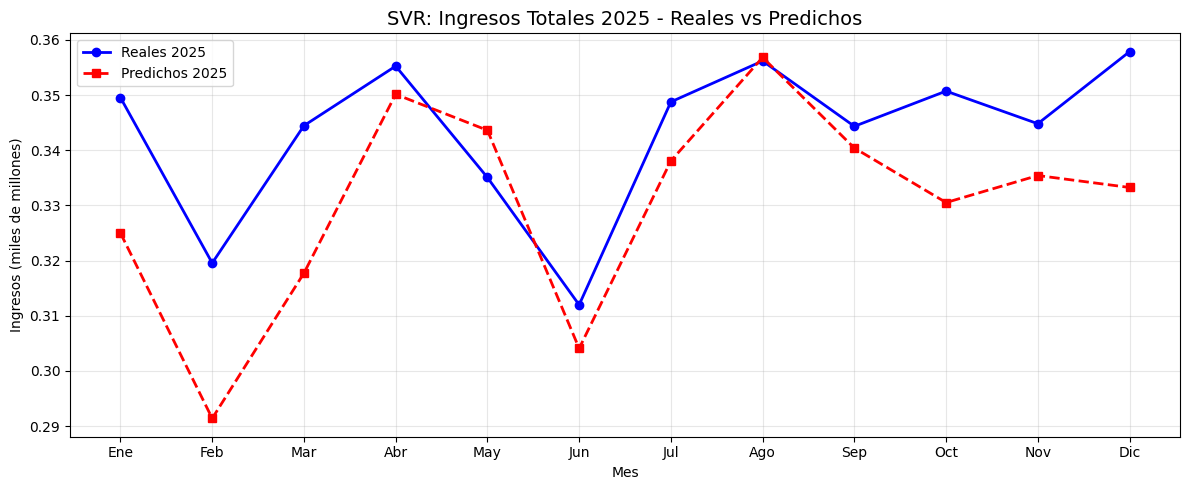

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
x_axis = range(1, 13)
meses_labels = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

ax.plot(x_axis, y_val.values / 1e9, 'b-o', label='Reales 2025', linewidth=2)
ax.plot(x_axis, y_pred_val / 1e9, 'r--s', label='Predichos 2025', linewidth=2)
ax.set_xticks(x_axis)
ax.set_xticklabels(meses_labels)
ax.set_title('SVR: Ingresos Totales 2025 - Reales vs Predichos', fontsize=14)
ax.set_xlabel('Mes')
ax.set_ylabel('Ingresos (miles de millones)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Predicción de Ingresos Totales 2026

In [8]:
meses_nombre = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio",
                "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]

predict_2026 = pd.DataFrame()
for i, mes in enumerate(meses_nombre):
    row = {
        "Año": 2026,
        "Mes": mes,
        "Num_Mes": i + 1,
        "Mes_Indice": 72 + i,
    }
    month_avg = df[df["Mes"] == mes][features[:-2]].mean()
    for feat in features[:-2]:
        row[feat] = month_avg[feat]
    predict_2026 = pd.concat([predict_2026, pd.DataFrame([row])], ignore_index=True)

X_2026 = predict_2026[features]
X_2026_scaled = scaler_X.transform(X_2026)
pred_2026_scaled = model.predict(X_2026_scaled)
predicciones_2026 = scaler_y.inverse_transform(pred_2026_scaled.reshape(-1, 1)).ravel()
predict_2026["Ingresos Totales Predichos"] = predicciones_2026

print("=== Predicción de Ingresos Totales 2026 ===")
for _, row in predict_2026.iterrows():
    print(f"{row['Mes']:12s}: ${row['Ingresos Totales Predichos']:>18,.0f}")

total_2026 = predict_2026["Ingresos Totales Predichos"].sum()
print(f"\n{'Total 2026':12s}: ${total_2026:>18,.0f}")

=== Predicción de Ingresos Totales 2026 ===
Enero       : $       349,009,906
Febrero     : $       327,135,903
Marzo       : $       347,095,940
Abril       : $       354,075,033
Mayo        : $       356,709,567
Junio       : $       332,890,426
Julio       : $       352,668,927
Agosto      : $       346,998,212
Septiembre  : $       343,825,975
Octubre     : $       336,613,079
Noviembre   : $       344,129,577
Diciembre   : $       337,753,173

Total 2026  : $     4,128,905,719


## 8. Visualización de Tendencia Histórica y Predicción 2026

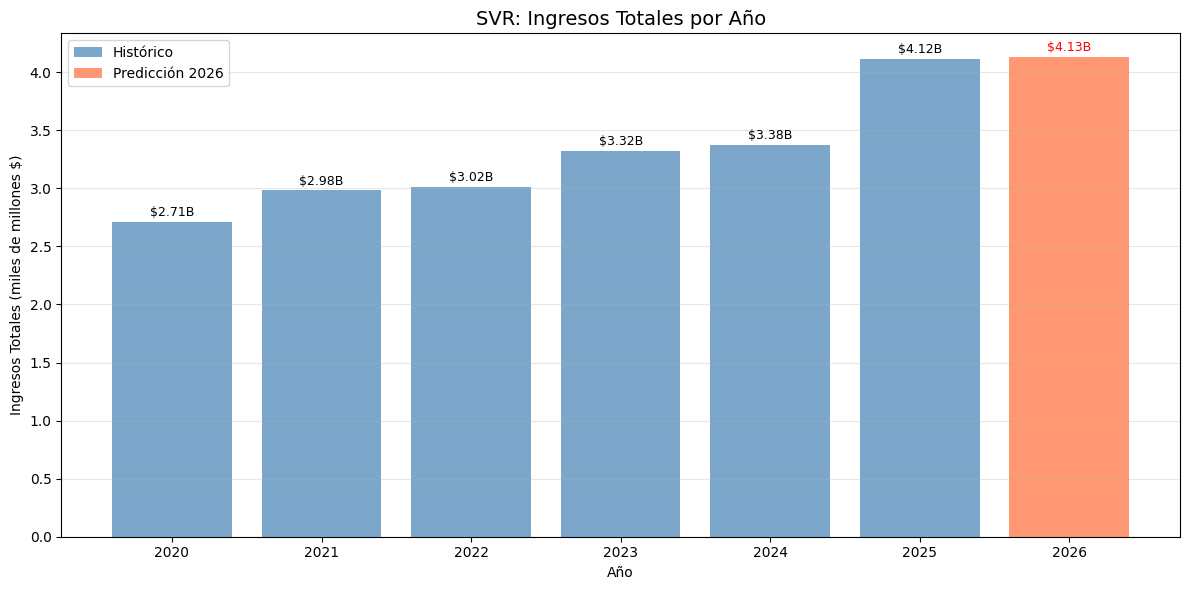

In [9]:
ingresos_anuales = df.groupby("Año")["Ingresos Totales"].sum()

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(ingresos_anuales.index.astype(str), ingresos_anuales.values / 1e9, 
       color='steelblue', alpha=0.7, label='Histórico')
ax.bar("2026", total_2026 / 1e9, color='coral', alpha=0.8, label='Predicción 2026')

for i, (year, val) in enumerate(ingresos_anuales.items()):
    ax.text(i, val / 1e9 + 0.05, f'${val/1e9:.2f}B', ha='center', fontsize=9)
ax.text(len(ingresos_anuales), total_2026 / 1e9 + 0.05, f'${total_2026/1e9:.2f}B', 
        ha='center', fontsize=9, color='red')

ax.set_title('SVR: Ingresos Totales por Año', fontsize=14)
ax.set_xlabel('Año')
ax.set_ylabel('Ingresos Totales (miles de millones $)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
predict_2026[["Año", "Mes", "Ingresos Totales Predichos"]].to_csv("prediccion_2026.csv", index=False)
print("Predicciones exportadas a prediccion_2026.csv")

Predicciones exportadas a prediccion_2026.csv


## Conclusiones
- SVR utiliza el truco del kernel (RBF) para capturar relaciones no lineales en el espacio de features.
- El tubo ε-insensible ignora errores menores, haciendo el modelo robusto a ruido pequeño.
- La regularización C controla el equilibrio entre la planitud del modelo y la tolerancia a errores.
- La escalación de features es fundamental para que las distancias en el kernel sean meaningful.
- Ventaja: efectivo en espacios de alta dimensionalidad y con datos moderados.
- Limitación: sensible a la selección de hiperparámetros, menos interpretable.